# Telemetry EDA — `g4o_audits` (dashboard MySQL)

Exploratory work on HTTP-style audit telemetry: `url`, `method`, `controller`, `action`, JSON payloads (`route_parameters`, `parameters`, `query`), `ip_address`, `user_agent`.

- **Part A** — temp slice, completeness, §4 routing & §4.a controller→action pairs, §5 daily volume & §5.a hourly, §6 single-row sample.
- **Part B** — timing heatmap (§7), method×controller pivot (§8), hostname/path parses (§9), coarse UA buckets (§10) & browser split (§10.a), company concentration curve (§11), **optional choropleth** from IPs with GeoLite2 + plotly (§12), **`parameters` JSON inventory** (§13).

**Session note:** MySQL `TEMPORARY` tables are tied to **one database connection**. This notebook opens a single `conn` and reuses it so `tmp_audit_telemetry` stays visible. Closing the notebook kernel or reconnecting requires re-running the temp-table cell.

## 1. Setup & connection

Defaults match [bansila-dashboard-mvp/docker-compose.yml](../bansila-dashboard-mvp/docker-compose.yml). Override via environment variables if needed (`MYSQL_HOST`, `MYSQL_PORT`, `MYSQL_USER`, `MYSQL_PASSWORD`, `MYSQL_DATABASE`).

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

_COMMA_INT = FuncFormatter(lambda x, p: f"{x:,.0f}")
_PCT_AXIS_1DP = FuncFormatter(lambda x, p: f"{x:.1f}")


def _comma_x(ax):
    ax.xaxis.set_major_formatter(_COMMA_INT)


def _comma_y(ax):
    ax.yaxis.set_major_formatter(_COMMA_INT)


import numpy as np
import pandas as pd
import seaborn as sns
from IPython import get_ipython
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 4), "figure.dpi": 110})

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

MYSQL_HOST = os.environ.get("MYSQL_HOST", "127.0.0.1")
MYSQL_PORT = int(os.environ.get("MYSQL_PORT", "3306"))
MYSQL_USER = os.environ.get("MYSQL_USER", "root")
MYSQL_PASSWORD = os.environ.get("MYSQL_PASSWORD", "bansila_root")
MYSQL_DB = os.environ.get("MYSQL_DATABASE", "bansila_analytics")

engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}",
    pool_pre_ping=True,
)
# One connection for the whole notebook (required for TEMPORARY tables)
conn = engine.connect()

print(f"Connected: {MYSQL_DB} @ {MYSQL_HOST}:{MYSQL_PORT} as {MYSQL_USER}")
_one = pd.read_sql(text("SELECT 1 AS ok"), conn)
display(_one)

Connected: bansila_analytics @ 127.0.0.1:3306 as root


,ok
0,1


## 2. Temporary slice: audits since cutoff

Adjust `TELEMETRY_SINCE` to match when rich telemetry landed in prod. Rows are filtered only by `created_at` here; downstream cells add `company_id` / `user_id` predicates as needed.

In [3]:
TELEMETRY_SINCE = "2026-02-12 04:00:00"

# Idempotent rebuild for this session
conn.execute(text("DROP TEMPORARY TABLE IF EXISTS tmp_audit_telemetry"))
conn.commit()

ddl = text(f"""
CREATE TEMPORARY TABLE tmp_audit_telemetry AS
SELECT *
FROM g4o_audits
WHERE created_at >= :ts
""")
conn.execute(ddl, {"ts": TELEMETRY_SINCE})
conn.commit()

meta = pd.read_sql(
    text("""
    SELECT
        COUNT(*) AS n_rows,
        MIN(created_at) AS min_created,
        MAX(created_at) AS max_created
    FROM tmp_audit_telemetry
    """),
    conn,
)
display(meta)

# Example analyst filter — same rows you sketched
sample_identified = pd.read_sql(
    text("""
    SELECT *
    FROM tmp_audit_telemetry
    WHERE 
        company_id IS NOT NULL AND 
        company_id != 97       AND
        user_id    IS NOT NULL AND
        user_id    != 0
    LIMIT 5
    """),
    conn,
)
print("Preview (identified company + user):")
display(sample_identified)

,n_rows,min_created,max_created
0,961463,2026-02-12 04:17:49,2026-04-21 05:55:58


Preview (identified company + user):


,id,company_id,user_id,auditable_id,auditable_type,deleted_at,created_at,updated_at,url,method,route_parameters,controller,action,parameters,query,ip_address,user_agent
0,11281099,7870,8050,None,None,None,2026-02-12 06:35:45,2026-02-12 06:35:45,https://bansi.la/accounting/accounting-codes,POST,[],App\Http\Controllers\Accounting\AccountingCodes,store,"{""code"": ""2381.0101"", ""name"": {""en"": null, ""lo...",[],115.84.116.90,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
1,11281122,7870,8050,None,None,None,2026-02-12 06:45:13,2026-02-12 06:45:13,https://bansi.la/accounting/accounting-codes/4...,PATCH,"{""accounting_code"": ""4388802""}",App\Http\Controllers\Accounting\AccountingCodes,update,"{""code"": ""4201.0101"", ""name"": {""en"": ""Employee...",[],115.84.116.90,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
2,11281127,7870,8050,None,None,None,2026-02-12 06:47:17,2026-02-12 06:47:17,https://bansi.la/accounting/accounting-codes/4...,PATCH,"{""accounting_code"": ""4388827""}",App\Http\Controllers\Accounting\AccountingCodes,update,"{""code"": ""631.0101"", ""name"": {""en"": ""Personnel...",[],115.84.116.90,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
3,11281130,7870,8050,None,None,None,2026-02-12 06:48:17,2026-02-12 06:48:17,https://bansi.la/accounting/accounting-codes,POST,[],App\Http\Controllers\Accounting\AccountingCodes,store,"{""code"": ""631.0102"", ""name"": {""en"": null, ""lo""...",[],115.84.116.90,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
4,11281133,7870,8050,None,None,None,2026-02-12 06:48:53,2026-02-12 06:48:53,https://bansi.la/accounting/accounting-codes,POST,[],App\Http\Controllers\Accounting\AccountingCodes,store,"{""code"": ""631,0102"", ""name"": {""en"": null, ""lo""...",[],115.84.116.90,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...


## 3. Completeness: which telemetry fields are populated?

Share of rows where each telemetry column has a “real” value: **SQL NULL** counts as empty. For `route_parameters`, `parameters`, and `query`, **`[]` and `{}`** (and JSON `null`) count as empty because they carry no payload, even though they are not SQL NULL.

`user_agent` must also be non-blank once cast to text.

,n_total,has_url,has_method,has_controller,has_action,has_route_parameters,has_parameters,has_query,has_ip_address,has_user_agent
0,712516,712516.0,712516.0,712516.0,712516.0,412743.0,711622.0,18712.0,712516.0,712516.0


,has_url,has_method,has_controller,has_action,has_route_parameters,has_parameters,has_query,has_ip_address,has_user_agent
pct_filled,100.0,100.0,100.0,100.0,57.93,99.87,2.63,100.0,100.0


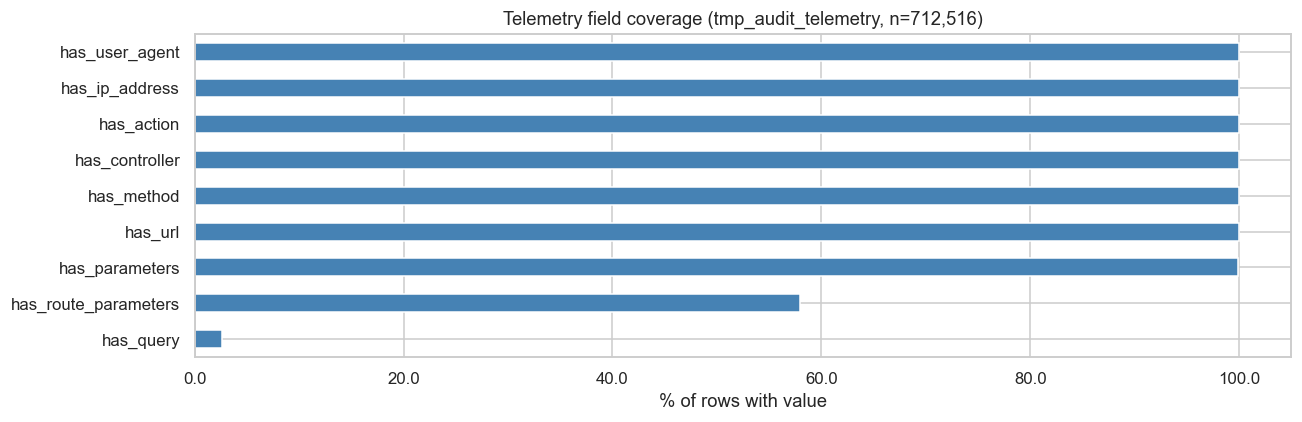

In [3]:
telemetry_cols = [
    "url",
    "method",
    "controller",
    "action",
    "route_parameters",
    "parameters",
    "query",
    "ip_address",
    "user_agent",
]

# JSON columns: treat SQL NULL, empty arrays/objects, and JSON null as "not populated"
JSON_TELEMETRY_COLS = frozenset({"route_parameters", "parameters", "query"})


def _has_value_expr(c: str) -> str:
    if c in JSON_TELEMETRY_COLS:
        return (
            f"`{c}` IS NOT NULL AND NOT ("
            f"(JSON_TYPE(`{c}`) IN ('ARRAY', 'OBJECT') AND JSON_LENGTH(`{c}`) = 0) "
            f"OR JSON_TYPE(`{c}`) = 'NULL' "
            f"OR TRIM(CAST(`{c}` AS CHAR)) IN ('[]', '{{}}')"
            f")"
        )
    if c == "user_agent":
        return f"`{c}` IS NOT NULL AND CAST(`{c}` AS CHAR) <> ''"
    return f"`{c}` IS NOT NULL"


cases = ",\n".join([f"SUM(CASE WHEN {_has_value_expr(c)} THEN 1 ELSE 0 END) AS has_{c}" for c in telemetry_cols])

completeness = pd.read_sql(
    text(f"""SELECT COUNT(*) AS n_total,
         {cases}
         FROM tmp_audit_telemetry
         WHERE 
            company_id IS NOT NULL AND
            company_id != 97       AND
            user_id    IS NOT NULL AND
            user_id    != 0
         """),
    conn,
)
n_tot = completeness["n_total"].iloc[0]
pct = completeness.drop(columns=["n_total"]).apply(lambda s: 100.0 * s / n_tot)
pct.index = ["pct_filled"]
display(completeness)
display(pct.round(2))

_ax = pct.T.squeeze().sort_values().plot.barh(color="steelblue")
_ax.set_xlabel("% of rows with value")
_ax.set_title(f"Telemetry field coverage (tmp_audit_telemetry, n={n_tot:,})")
_ax.xaxis.set_major_formatter(_PCT_AXIS_1DP)
plt.tight_layout()
plt.show()

## 4. HTTP routing (identified users)

Same analyst filters as §3 (`company_id` / `user_id` required; excluding `company_id = 97` and `user_id = 0`).

**Route shorthand:** strip the prefix `App\\Http\\Controllers\\`, drop a trailing `Controller` on the final class segment, split PHP namespaces on backslashes, join segments with `>` for charts/tables. Labels are **lowercased** for readability (e.g. `App\\Http\\Controllers\\Income\\CustomersController` → `income>customers`). HTTP method breakdown is unchanged.

Top-N queries use `:top_k` bound parameters. **§4.a** (next cells) ranks **`route>…>action`** pairs.


,method,n
0,POST,474841
1,PATCH,106344
2,PUT,71808
3,DELETE,57825
4,HEAD,1698


,controller,_route,n
0,App\Http\Controllers\Incomes\Invoices,Incomes>Invoices,181691
1,App\Http\Controllers\Accounting\JournalEntries,Accounting>JournalEntries,147727
2,App\Http\Controllers\Expenses\Bills,Expenses>Bills,46585
3,App\Http\Controllers\Incomes\InvoiceRevenues,Incomes>InvoiceRevenues,43281
4,App\Http\Controllers\Accounting\GeneralJournals,Accounting>GeneralJournals,42132
5,App\Http\Controllers\Expenses\Payments,Expenses>Payments,39279
6,App\Http\Controllers\Incomes\Revenues,Incomes>Revenues,30885
7,App\Http\Controllers\Items\Movements,Items>Movements,30370
8,App\Http\Controllers\Accounting\AccountingCodes,Accounting>AccountingCodes,20003
9,App\Http\Controllers\Companies\CurrentCompanie...,Companies>CurrentCompanies,18713


,action,n
0,store,324074
1,update,168608
2,invoice,52412
3,vat,37495
4,destroy,34142
5,locked,16726
6,bill,15284
7,import,11211
8,duplicate,6213
9,total,5630


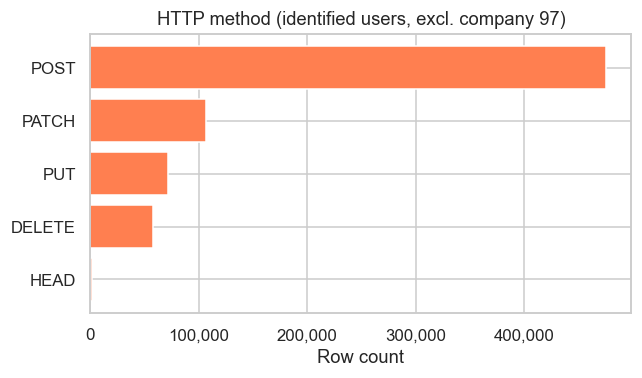

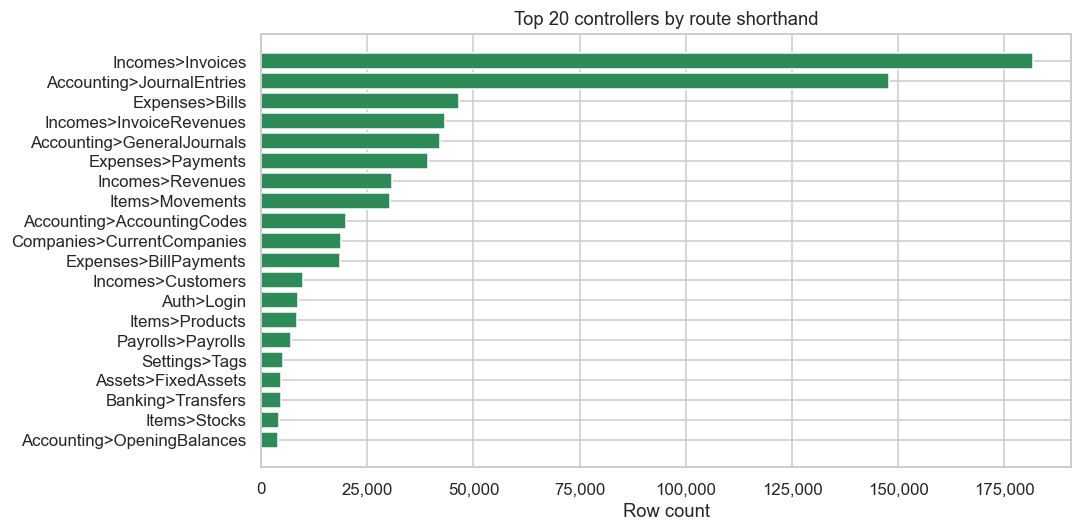

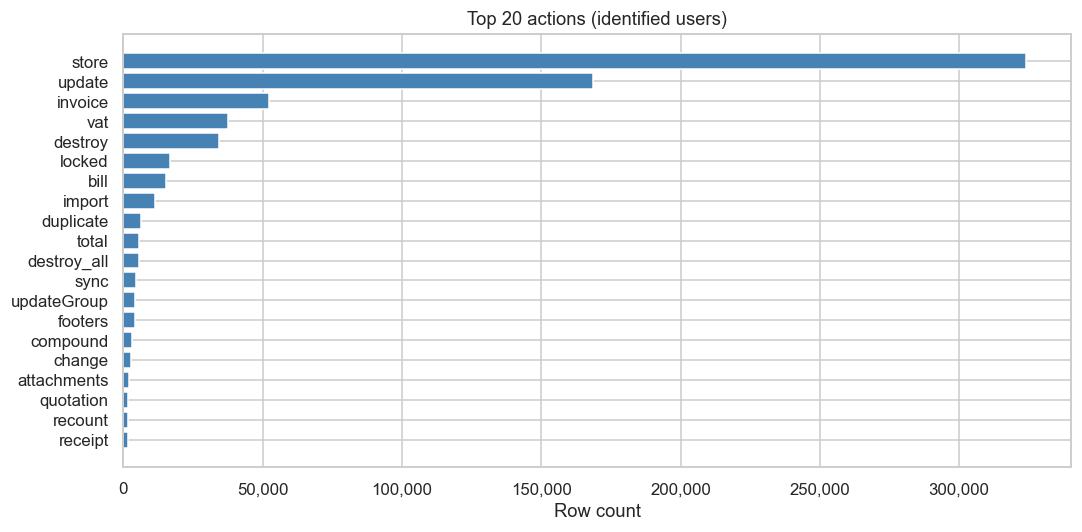

In [4]:
TOP_K = 20

_BS = chr(92)
_CONTROLLER_PREFIX = f"App{_BS}Http{_BS}Controllers{_BS}"


def controller_route_label(controller: object) -> str:
    """Strip App\Http\Controllers\, drop trailing Controller on last segment, join as area>sub>... (lowercase)."""
    s = str(controller).strip()
    if not s or s.lower() in {"nan", "none"}:
        return "(unknown)"
    if s.startswith(_CONTROLLER_PREFIX):
        s = s[len(_CONTROLLER_PREFIX) :]
    parts = [p for p in s.split(_BS) if p]
    if not parts:
        return "(unknown)"
    last = parts[-1]
    suf = "Controller"
    if len(last) > len(suf) and last.endswith(suf):
        parts[-1] = last[: -len(suf)]
    return ">".join(p for p in parts)


method_df = pd.read_sql(
    text("""
    SELECT COALESCE(method, '(null)') AS method, COUNT(*) AS n
    FROM tmp_audit_telemetry
    WHERE company_id IS NOT NULL
      AND company_id <> 97
      AND user_id IS NOT NULL
      AND user_id <> 0
    GROUP BY COALESCE(method, '(null)')
    ORDER BY n DESC
    """),
    conn,
)
display(method_df.head(15))

_fig, _ax = plt.subplots(figsize=(6, 3.6))
method_vis = method_df.head(12).iloc[::-1]
_ax.barh(method_vis["method"], method_vis["n"], color="coral")
_ax.set_title("HTTP method (identified users, excl. company 97)")
_ax.set_xlabel("Row count")
_comma_x(_ax)
plt.tight_layout()

ctrl_df = pd.read_sql(
    text("""
    SELECT controller, COUNT(*) AS n
    FROM tmp_audit_telemetry
    WHERE company_id IS NOT NULL
      AND company_id <> 97
      AND user_id IS NOT NULL
      AND user_id <> 0
      AND controller IS NOT NULL
    GROUP BY controller
    ORDER BY n DESC
    LIMIT :top_k
    """),
    conn,
    params={"top_k": int(TOP_K)},
)

ctrl_df["_route"] = ctrl_df["controller"].map(controller_route_label)

_fig, _ax = plt.subplots(figsize=(10, 5))
cv = ctrl_df.iloc[::-1].copy()
_ax.barh(cv["_route"], cv["n"], color="seagreen")
_ax.set_title(f"Top {TOP_K} controllers by route shorthand")
_ax.set_xlabel("Row count")
_comma_x(_ax)
plt.tight_layout()

action_df = pd.read_sql(
    text("""
    SELECT action, COUNT(*) AS n
    FROM tmp_audit_telemetry
    WHERE company_id IS NOT NULL
      AND company_id <> 97
      AND user_id IS NOT NULL
      AND user_id <> 0
      AND action IS NOT NULL
    GROUP BY action
    ORDER BY n DESC
    LIMIT :top_k
    """),
    conn,
    params={"top_k": int(TOP_K)},
)

_fig, _ax = plt.subplots(figsize=(10, 5))
av = action_df.iloc[::-1]
_ax.barh(av["action"].astype(str), av["n"], color="steelblue")
_ax.set_title(f"Top {TOP_K} actions (identified users)")
_ax.set_xlabel("Row count")
_comma_x(_ax)
plt.tight_layout()

display(ctrl_df[["controller", "_route", "n"]])
display(action_df)
plt.show()



### 4.a Controller→action pairs

Grouped row counts per Laravel **`controller` + `action`**. **`pair`** is `route>…>action` using the same shorthand as §4; the table keeps the raw `controller` string for grep/stack-trace alignment.


,pair,n,controller,action
0,Accounting>JournalEntries → update,71775,App\Http\Controllers\Accounting\JournalEntries,update
1,Accounting>JournalEntries → store,65041,App\Http\Controllers\Accounting\JournalEntries,store
2,Incomes>Invoices → invoice,52412,App\Http\Controllers\Incomes\Invoices,invoice
3,Incomes>Invoices → store,44833,App\Http\Controllers\Incomes\Invoices,store
4,Incomes>InvoiceRevenues → store,37906,App\Http\Controllers\Incomes\InvoiceRevenues,store
5,Incomes>Invoices → vat,33014,App\Http\Controllers\Incomes\Invoices,vat
6,Expenses>Payments → store,28532,App\Http\Controllers\Expenses\Payments,store
7,Incomes>Invoices → update,26514,App\Http\Controllers\Incomes\Invoices,update
8,Items>Movements → store,23845,App\Http\Controllers\Items\Movements,store
9,Accounting>GeneralJournals → store,20490,App\Http\Controllers\Accounting\GeneralJournals,store


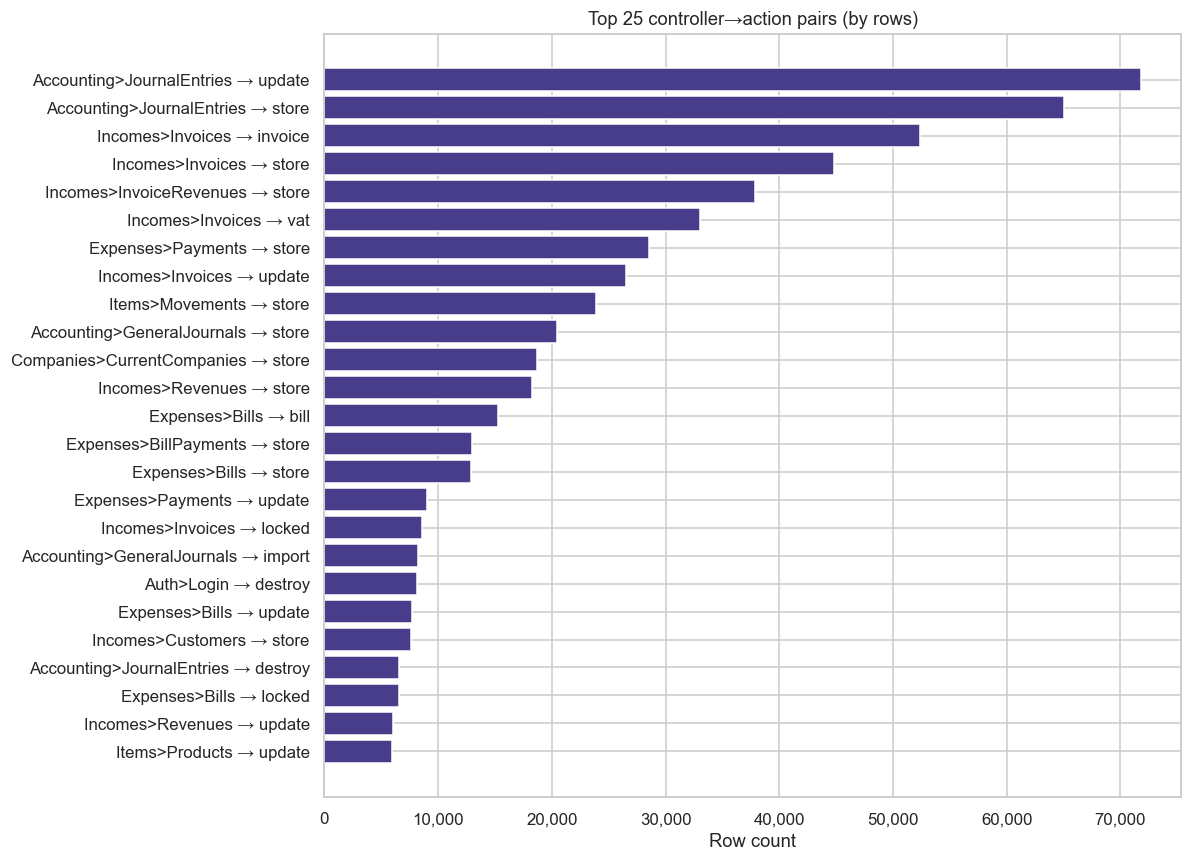

In [5]:
PAIR_TOP_K = 25

_ident_filter = """
    company_id IS NOT NULL
      AND company_id <> 97
      AND user_id IS NOT NULL
      AND user_id <> 0
"""

pair_df = pd.read_sql(
    text(f"""
    SELECT controller, action, COUNT(*) AS n
    FROM tmp_audit_telemetry
    WHERE {_ident_filter}
      AND controller IS NOT NULL
      AND TRIM(CAST(controller AS CHAR)) <> ''
      AND action IS NOT NULL
      AND TRIM(CAST(action AS CHAR)) <> ''
    GROUP BY controller, action
    ORDER BY n DESC
    LIMIT :top_k
    """),
    conn,
    params={"top_k": int(PAIR_TOP_K)},
)

pair_df["_route"] = pair_df["controller"].map(controller_route_label)
pair_df["pair"] = pair_df["_route"].astype(str) + " → " + pair_df["action"].astype(str).str.strip()

pv = pair_df.iloc[::-1].copy()
_fig, _ax = plt.subplots(figsize=(11, max(5.5, len(pv) * 0.32)))
_ax.barh(pv["pair"], pv["n"], color="darkslateblue")
_ax.set_title(f"Top {PAIR_TOP_K} controller→action pairs (by rows)")
_ax.set_xlabel("Row count")
_comma_x(_ax)
plt.tight_layout()

display(pair_df[["pair", "n", "controller", "action"]].reset_index(drop=True))
plt.show()



### 4.b Category-specific Controller Rankings

Instead of a global ranking, we group and rank each controller (including nested sub-controllers) within its respective top-level category (e.g., `Incomes`, `Accounting`, `Expenses`).

In [ ]:
ctrl_all_df = pd.read_sql(
    text("""
    SELECT controller, COUNT(*) AS n
    FROM tmp_audit_telemetry
    WHERE {_ident_filter}
      AND controller IS NOT NULL
    GROUP BY controller
    ORDER BY n DESC
    """),
    conn,
)

ctrl_all_df["_route"] = ctrl_all_df["controller"].map(controller_route_label)

def get_category_from_route(route):
    parts = route.split(">")
    if len(parts) > 1:
        return parts[0]
    return "Other"

ctrl_all_df["category"] = ctrl_all_df["_route"].map(get_category_from_route)
ctrl_all_df["rank"] = ctrl_all_df.groupby("category")["n"].rank(ascending=False, method="first").astype(int)

ctrl_ranked_df = ctrl_all_df.sort_values(by=["category", "rank"]).reset_index(drop=True)
display_df = ctrl_ranked_df[["category", "rank", "_route", "n", "controller"]].rename(
    columns={
        "category": "Category",
        "rank": "Rank",
        "_route": "Route Shorthand",
        "n": "Row Count (n)",
        "controller": "Controller Class"
    }
)

pd.set_option('display.max_rows', 100)
display(display_df)


,Category,Rank,Route Shorthand,Row Count (n),Controller Class
0,Accounting,1,Accounting>JournalEntries,147727,App\Http\Controllers\Accounting\JournalEntries
1,Accounting,2,Accounting>GeneralJournals,42132,App\Http\Controllers\Accounting\GeneralJournals
2,Accounting,3,Accounting>AccountingCodes,20003,App\Http\Controllers\Accounting\AccountingCodes
3,Accounting,4,Accounting>OpeningBalances,4044,App\Http\Controllers\Accounting\OpeningBalances
4,Accounting,5,Accounting>CloseAccounts,3284,App\Http\Controllers\Accounting\CloseAccounts
5,Accounting,6,Accounting>Remarks,1560,App\Http\Controllers\Accounting\Remarks
6,Accounting,7,Accounting>Adjustments,600,App\Http\Controllers\Accounting\Adjustments
7,Accounting,8,Accounting>TaxesDeclarationSummary,282,App\Http\Controllers\Accounting\TaxesDeclarati...
8,Accounting,9,Accounting>IncomesComparisonStatement,218,App\Http\Controllers\Accounting\IncomesCompari...
9,Accounting,10,Accounting>JournalBooks,173,App\Http\Controllers\Accounting\JournalBooks


### 4.c Category-specific Auditable Type Rankings

Similarly, we group and rank each auditable model type (e.g. `App\Models\Expense\Payment`) within its respective category (e.g. `Expense`).

In [5]:
_ident_filter = """
    company_id IS NOT NULL
      AND company_id <> 97
      AND user_id IS NOT NULL
      AND user_id <> 0
"""

auditable_all_df = pd.read_sql(
    text(f"""
    SELECT auditable_type, COUNT(*) AS n
    FROM g4o_audits
    WHERE {_ident_filter}
      AND auditable_type IS NOT NULL
      AND TRIM(CAST(auditable_type AS CHAR)) <> ''
    GROUP BY auditable_type
    ORDER BY n DESC
    """),
    conn,
)

_MODEL_PREFIX = "App\\Models\\"
_BS = "\\"

def auditable_type_route_label(s):
    if not s or not isinstance(s, str):
        return "(unknown)"
    if s.startswith(_MODEL_PREFIX):
        s = s[len(_MODEL_PREFIX) :]
    parts = [p for p in s.split(_BS) if p]
    if not parts:
        return "(unknown)"
    return ">".join(p for p in parts)

auditable_all_df["_route"] = auditable_all_df["auditable_type"].map(auditable_type_route_label)

def get_category_from_route(route):
    parts = route.split(">")
    if len(parts) > 1:
        return parts[0]
    return "Other"

auditable_all_df["category"] = auditable_all_df["_route"].map(get_category_from_route)
auditable_all_df["rank"] = auditable_all_df.groupby("category")["n"].rank(ascending=False, method="first").astype(int)

auditable_ranked_df = auditable_all_df.sort_values(by=["category", "rank"]).reset_index(drop=True)
display_df = auditable_ranked_df[["category", "rank", "_route", "n", "auditable_type"]].rename(
    columns={
        "category": "Category",
        "rank": "Rank",
        "_route": "Route Shorthand",
        "n": "Row Count (n)",
        "auditable_type": "Auditable Type"
    }
)

pd.set_option('display.max_rows', 100)
display(display_df)


,Category,Rank,Route Shorthand,Row Count (n),Auditable Type
0,Banking,1,Banking>Account,10129,App\Models\Banking\Account
1,Expense,1,Expense>Bill,1114606,App\Models\Expense\Bill
2,Expense,2,Expense>Payment,791693,App\Models\Expense\Payment
3,Income,1,Income>Invoice,7703401,App\Models\Income\Invoice
4,Income,2,Income>Revenue,1004460,App\Models\Income\Revenue
5,Item,1,Item>Movement,36768,App\Models\Item\Movement
6,Payroll,1,Payroll>Employee,8936,App\Models\Payroll\Employee
7,Setting,1,Setting>Currency,7644,App\Models\Setting\Currency
8,Setting,2,Setting>Affiliate,13,App\Models\Setting\Affiliate


## 5. Volume over time — daily

Same analyst filters as §3. One row per calendar day via **`DATE(created_at)`**.

**§5.a** (cells below) repeats the same metrics with **hourly** buckets using **`DATE_FORMAT`**.


,d,n,n_companies,n_users
59,2026-04-12,1582,71,76
60,2026-04-13,4269,144,147
61,2026-04-14,1221,45,56
62,2026-04-15,1106,42,46
63,2026-04-16,610,47,49
64,2026-04-17,4083,113,121
65,2026-04-18,2583,111,118
66,2026-04-19,2324,100,89
67,2026-04-20,10836,343,329
68,2026-04-21,81,6,6


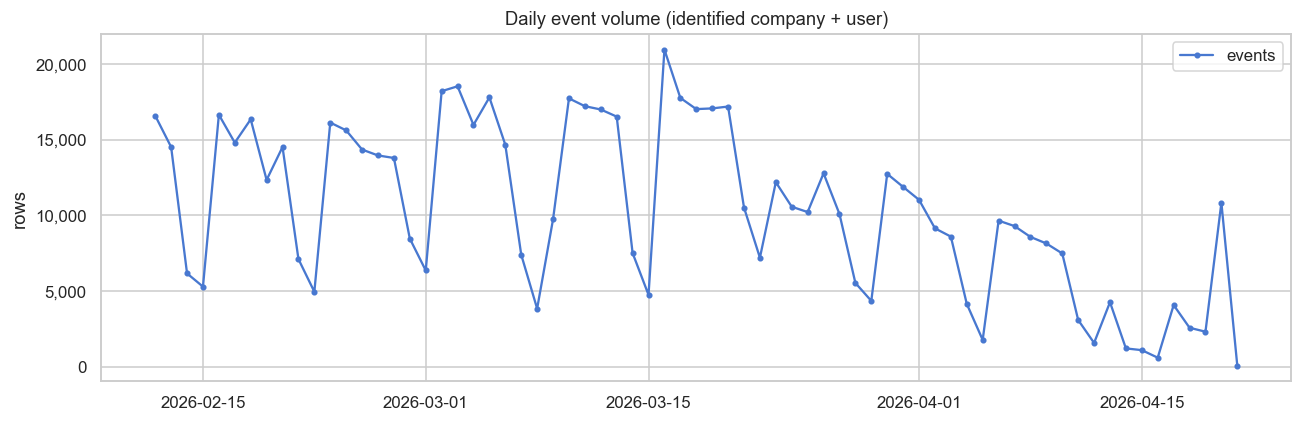

In [8]:
daily = pd.read_sql(
    text("""
    SELECT
        DATE(created_at) AS d,
        COUNT(*) AS n,
        COUNT(DISTINCT company_id) AS n_companies,
        COUNT(DISTINCT user_id) AS n_users
    FROM tmp_audit_telemetry
    WHERE 
        company_id IS NOT NULL AND
        company_id != 97       AND
        user_id    IS NOT NULL AND
        user_id    != 0
    GROUP BY DATE(created_at)
    ORDER BY d
    """),
    conn,
    parse_dates=["d"],
)

_fig, _ax = plt.subplots(figsize=(12, 4))
_ax.plot(daily["d"], daily["n"], marker="o", markersize=3, label="events")
_ax.set_title("Daily event volume (identified company + user)")
_ax.set_ylabel("rows")
_ax.legend()
_comma_y(_ax)
plt.tight_layout()
display(daily.tail(10))
plt.show()

### 5.a Hourly event volume

Counts grouped by **UTC hour** (adjust in SQL if `created_at` is stored in another zone). Wide date ranges produce many points — zoom the matplotlib figure or slice `TELEMETRY_SINCE` / add a `WHERE created_at >= ...` clause if needed.


,h,n,n_companies,n_users
0,2026-02-12 06:00:00,19,2,2
1,2026-02-12 07:00:00,130,10,8
2,2026-02-12 08:00:00,576,94,83
3,2026-02-12 09:00:00,1732,163,149
4,2026-02-12 10:00:00,1997,175,167
5,2026-02-12 11:00:00,1502,154,144
6,2026-02-12 12:00:00,610,76,65
7,2026-02-12 13:00:00,1284,126,118
8,2026-02-12 14:00:00,2112,158,143
9,2026-02-12 15:00:00,2522,167,164


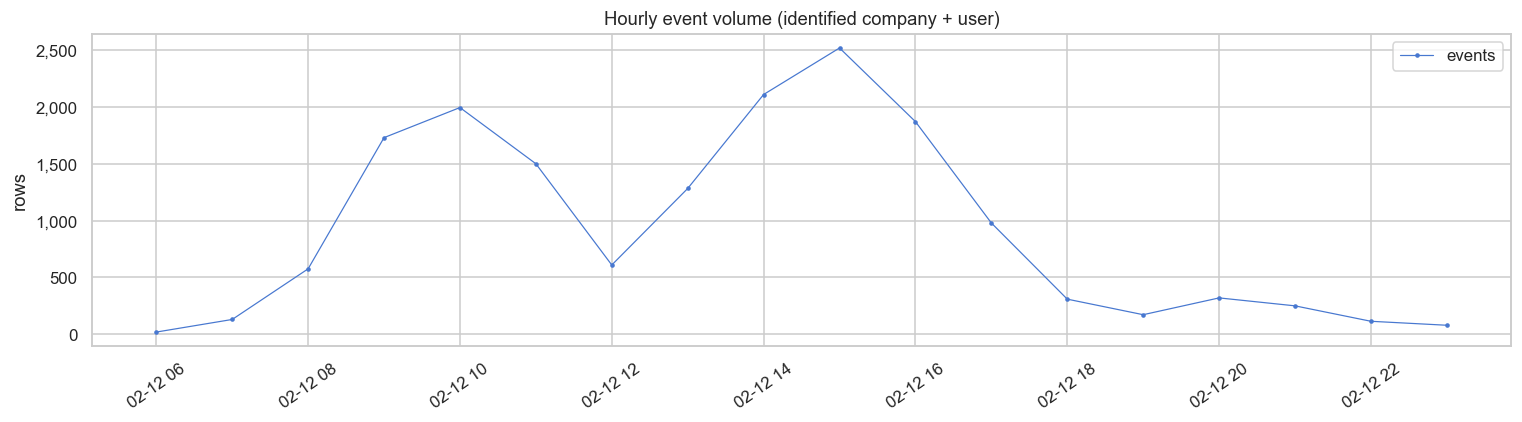

In [9]:
hourly = pd.read_sql(
    text("""
    SELECT
        DATE_FORMAT(created_at, '%Y-%m-%d %H:00:00') AS h,
        COUNT(*) AS n,
        COUNT(DISTINCT company_id) AS n_companies,
        COUNT(DISTINCT user_id) AS n_users
    FROM tmp_audit_telemetry
    WHERE
        company_id IS NOT NULL AND
        company_id != 97       AND
        user_id    IS NOT NULL AND
        user_id    != 0        AND
        DATE(created_at) = '2026-02-12'
    GROUP BY DATE_FORMAT(created_at, '%Y-%m-%d %H:00:00')
    ORDER BY h
    """),
    conn,
    parse_dates=["h"],
)

_fig, _ax = plt.subplots(figsize=(14, 4))
_ax.plot(hourly["h"], hourly["n"], marker=".", markersize=4, linestyle="-", linewidth=0.8, label="events")
_ax.set_title("Hourly event volume (identified company + user)")
_ax.set_ylabel("rows")
_ax.tick_params(axis="x", rotation=35)
_ax.legend()
_comma_y(_ax)
plt.tight_layout()
display(hourly.head(15))
plt.show()



## 6. Example deep row (JSON truncated in display)

Inspect one rich row; expand in SQL or export if payloads are large.

**Why not `ORDER BY id DESC LIMIT 1` here?** The session temp table is usually a **heap with no index on `id`**, so MySQL may try a large **filesort** and hit **1038 (Out of sort memory)**. The cell below loads the same row in two stages: **`SELECT MAX(id)`** under the filters (only bigint work), then **`WHERE id = :mid`** to pull the JSON/heavy columns for that single key.

In [10]:
# Two-step avoids ORDER BY ... LIMIT on a heap temp table (MySQL error 1038 / sort memory).
_mid = conn.execute(
    text("""
        SELECT MAX(id)
        FROM tmp_audit_telemetry
        WHERE company_id IS NOT NULL
          AND company_id <> 97
          AND user_id IS NOT NULL
          AND user_id <> 0
          AND url IS NOT NULL
          AND controller IS NOT NULL
    """)
).scalar()

if _mid is None:
    display(pd.DataFrame())
else:
    example = pd.read_sql(
        text("""
            SELECT id, company_id, user_id, created_at, url, method, controller, action,
                   route_parameters, parameters, query, ip_address,
                   LEFT(user_agent, 200) AS user_agent_head
            FROM tmp_audit_telemetry
            WHERE id = :mid
            """),
        conn,
        params={"mid": int(_mid)},
    )
    display(example.T)

,0
id,12242243
company_id,1
user_id,1
created_at,2026-04-21 05:51:00
url,https://bansi.la/accounting/journal-entries/41...
method,PUT
controller,App\Http\Controllers\Accounting\JournalEntries
action,update
route_parameters,"{""journal_entry"": ""41600932""}"
parameters,"{""date"": ""2026-04-20"", ""type"": ""invoice"", ""amo..."


---
## Part B — Deeper patterns & optional geo map

Uses the **same analyst filters** as §4 (`company_id` / `user_id` present; exclude `company_id = 97`, `user_id = 0`).

**GeoLite2 §12:** `pip install geoip2 plotly`, add **`GeoLite2-City.mmdb`** (see §12) via file path / `GEOIP2_CITY_DB`, or set **`MAXMIND_LICENSE_KEY`** to auto-download into **`.geoip_cache/`**.

**§13:** request-body **`parameters`** JSON — top-level keys, value kinds (sample), and **controller×action×key** counts for targeted deep dives.


### 7. Activity timing (weekday × hour heatmap)

`DAYOFWEEK` here: **1 = Sunday … 7 = Saturday** (MySQL).


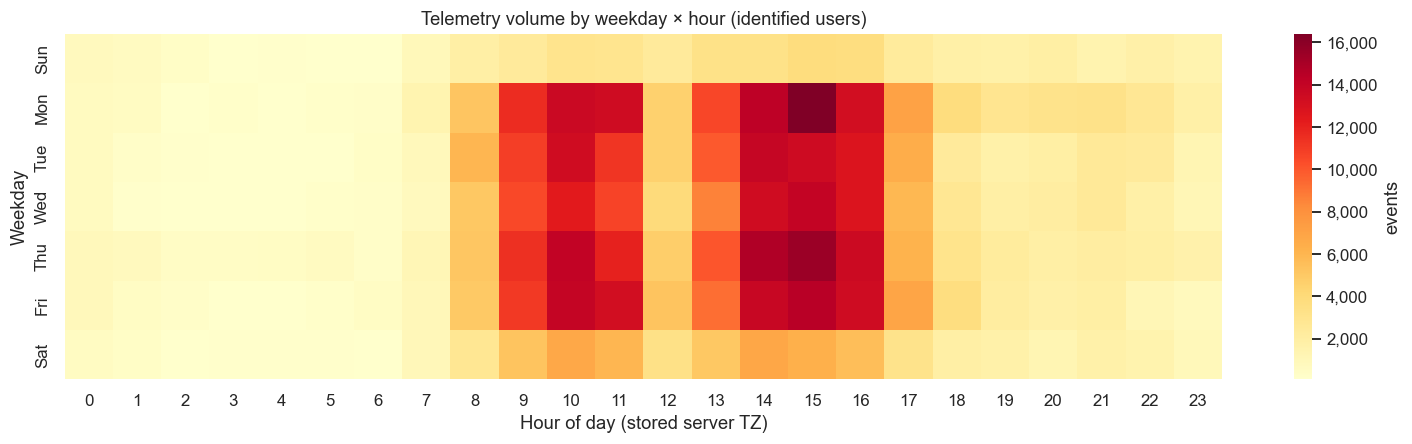

In [11]:
dow_hour = pd.read_sql(
    text(
        """
        SELECT DAYOFWEEK(created_at) AS dow,
               HOUR(created_at) AS hr,
               COUNT(*) AS n
        FROM tmp_audit_telemetry
        WHERE company_id IS NOT NULL
          AND company_id <> 97
          AND user_id IS NOT NULL
          AND user_id <> 0
        GROUP BY DAYOFWEEK(created_at), HOUR(created_at)
        """
    ),
    conn,
)

_pv = dow_hour.pivot(index="dow", columns="hr", values="n").fillna(0)
_dow_nm = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
_pv.index = _pv.index.map(lambda d: _dow_nm.get(int(d), str(d)))

_fig, _ax = plt.subplots(figsize=(14, 4.2))
sns.heatmap(_pv, cmap="YlOrRd", ax=_ax, cbar_kws={"label": "events", "format": _COMMA_INT})
_ax.set_title("Telemetry volume by weekday × hour (identified users)")
_ax.set_xlabel("Hour of day (stored server TZ)")
_ax.set_ylabel("Weekday")
plt.tight_layout()
plt.show()

### 8. HTTP method × controller (focused view)

**Top 12 controllers** overall, then pivot on **method**. Heatmap columns use the same **`xx>yy`** route shorthand as §4 (strip `App\\Http\\Controllers\\`, drop trailing `Controller`, lowercase).

**MySQL caveat:** You cannot scan the same **`TEMPORARY` table twice in one SQL statement**. A CTE + outer `FROM tmp_audit_telemetry` triggers **1137 / Can't reopen table**; this cell pulls the controller list first, then runs the aggregate.


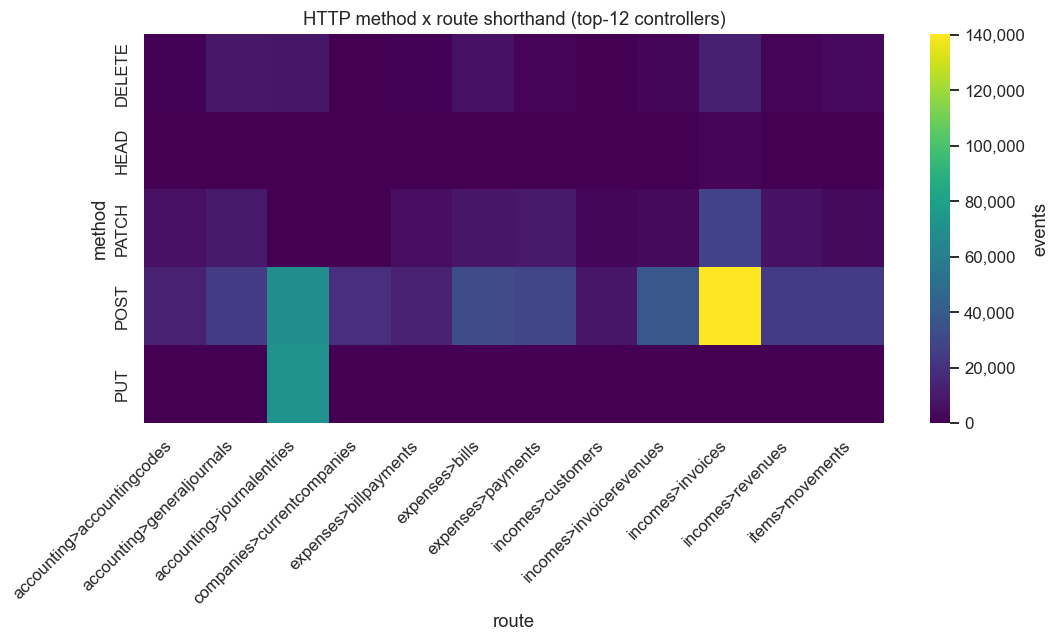

In [12]:
from sqlalchemy import bindparam

_BS = chr(92)
_CONTROLLER_PREFIX = f"App{_BS}Http{_BS}Controllers{_BS}"


def controller_route_label(controller: object) -> str:
    """Same shorthand as §4: strip App\Http\Controllers\, drop trailing Controller, join as area>sub (lowercase)."""
    s = str(controller).strip()
    if not s or s.lower() in {"nan", "none"}:
        return "(unknown)"
    if s.startswith(_CONTROLLER_PREFIX):
        s = s[len(_CONTROLLER_PREFIX) :]
    parts = [p for p in s.split(_BS) if p]
    if not parts:
        return "(unknown)"
    last = parts[-1]
    suf = "Controller"
    if len(last) > len(suf) and last.endswith(suf):
        parts[-1] = last[: -len(suf)]
    return ">".join(p.lower() for p in parts)


_top_df = pd.read_sql(
    text(
        """
        SELECT controller
        FROM tmp_audit_telemetry
        WHERE company_id IS NOT NULL
          AND company_id <> 97
          AND user_id IS NOT NULL
          AND user_id <> 0
          AND controller IS NOT NULL
        GROUP BY controller
        ORDER BY COUNT(*) DESC
        LIMIT 12
        """
    ),
    conn,
)

_clist = _top_df["controller"].tolist()
if not _clist:
    combos = pd.DataFrame(columns=["method", "controller", "n"])
else:
    combos = pd.read_sql(
        text(
            """
            SELECT COALESCE(method, '(null)') AS method, controller, COUNT(*) AS n
            FROM tmp_audit_telemetry
            WHERE company_id IS NOT NULL
              AND company_id <> 97
              AND user_id IS NOT NULL
              AND user_id <> 0
              AND controller IN :clist
            GROUP BY COALESCE(method, '(null)'), controller
            """
        ).bindparams(bindparam("clist", expanding=True)),
        conn,
        params={"clist": _clist},
    )

if combos.empty:
    _pivot = pd.DataFrame()
else:
    _agg = combos.assign(_route=combos["controller"].map(controller_route_label))
    _pivot = _agg.groupby(["method", "_route"], as_index=False)["n"].sum()
    _pivot = _pivot.pivot_table(index="method", columns="_route", values="n", fill_value=0)

if _pivot.shape[1] == 0:
    print("No controller column to plot (empty combos).")
else:
    _fig, _ax = plt.subplots(figsize=(10, max(6, len(_pivot) * 0.35)))
    sns.heatmap(_pivot, cmap="viridis", ax=_ax, cbar_kws={"label": "events", "format": _COMMA_INT})
    _ax.set_title("HTTP method x route shorthand (top-12 controllers)")
    _ax.set_ylabel("method")
    _ax.set_xlabel("route")
    plt.setp(_ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



### 9. Parsed URL hostname & first path segment

Uses **`SUBSTRING` / `SUBSTRING_INDEX` / `LOCATE`** (no `REGEXP_SUBSTR` capture groups—some MySQL builds reject the 6-argument form with **1582**). Strips `http(s)://`, drops query strings at `?`, then takes the first `/` path segment.


,host,path_seg1,n
0,bansi.la,incomes,249715
1,bansi.la,accounting,214458
2,bansi.la,expenses,110053
3,bansi.la,items,42452
4,bansi.la,companies,18754
5,www.bansi.la,incomes,16639
6,bansi.la,settings,12065
7,bansi.la,auth,11768
8,bansi.la,payrolls,8408
9,bansi.la,assets,6437


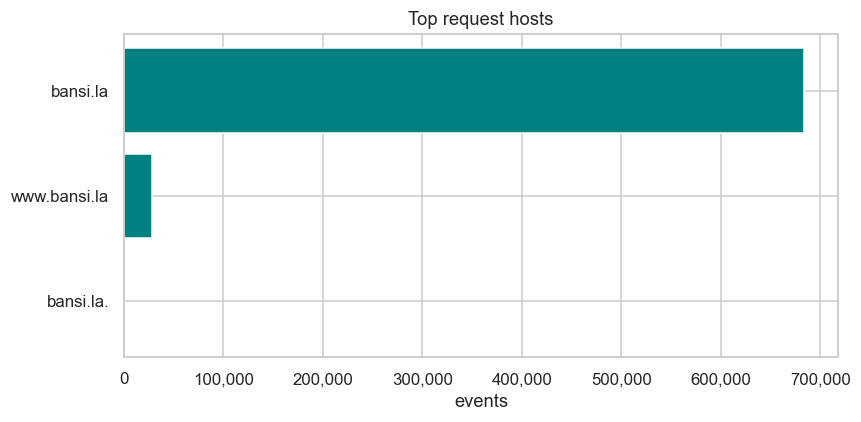

In [13]:
url_parts = pd.read_sql(
    text(
        """
SELECT zz.host AS host,
       zz.path_seg1 AS path_seg1,
       COUNT(*) AS n
FROM (
    SELECT
        SUBSTRING_INDEX(y.r1, '/', 1) AS host,
        CASE
            WHEN LOCATE('/', y.r1) = 0 THEN NULL
            ELSE SUBSTRING_INDEX(SUBSTRING(y.r1 FROM LOCATE('/', y.r1) + 1), '/', 1)
        END AS path_seg1
    FROM (

    SELECT SUBSTRING_INDEX(
               CASE WHEN TRIM(url) LIKE 'https://%' THEN SUBSTRING(TRIM(url), 9)
                    WHEN TRIM(url) LIKE 'http://%'  THEN SUBSTRING(TRIM(url), 8)
                    ELSE TRIM(url) END,
               '?', 1
           ) AS r1

        FROM tmp_audit_telemetry
        WHERE company_id IS NOT NULL
          AND company_id <> 97
          AND user_id IS NOT NULL
          AND user_id <> 0
          AND url IS NOT NULL
          AND TRIM(url) <> ''
    ) y
) zz
GROUP BY zz.host, zz.path_seg1
ORDER BY n DESC
LIMIT 25
        """
    ),
    conn,
)
display(url_parts)

_top_hosts = pd.read_sql(
    text(
        """
SELECT z.host AS host, COUNT(*) AS n
FROM (
    SELECT SUBSTRING_INDEX(y.r1, '/', 1) AS host
    FROM (

    SELECT SUBSTRING_INDEX(
               CASE WHEN TRIM(url) LIKE 'https://%' THEN SUBSTRING(TRIM(url), 9)
                    WHEN TRIM(url) LIKE 'http://%'  THEN SUBSTRING(TRIM(url), 8)
                    ELSE TRIM(url) END,
               '?', 1
           ) AS r1

        FROM tmp_audit_telemetry
        WHERE company_id IS NOT NULL AND company_id <> 97
          AND user_id IS NOT NULL AND user_id <> 0
          AND url IS NOT NULL AND TRIM(url) <> ''
    ) y
) z
GROUP BY z.host
ORDER BY n DESC
LIMIT 15
        """
    ),
    conn,
)
_fig, _ax = plt.subplots(figsize=(8, 4))
_th = _top_hosts.iloc[::-1]
_ax.barh(_th["host"].fillna("(unparsed)").astype(str), _th["n"], color="teal")
_ax.set_title("Top request hosts")
_ax.set_xlabel("events")
_comma_x(_ax)
plt.tight_layout()
plt.show()

### 10. Coarse buckets from `user_agent`

Lightweight heuristic (not fine-grained device detection): bots/monitors vs mobile-ish vs desktop/other.

**§10.a** — browser-family counts (Chrome / Safari / Firefox / Edge / …) using order-sensitive `CASE` patterns on `user_agent`; not a substitute for a proper UA parser.


,ua_bucket,n,pct
0,desktop / other,705317,98.99
1,mobile-ish,7199,1.01


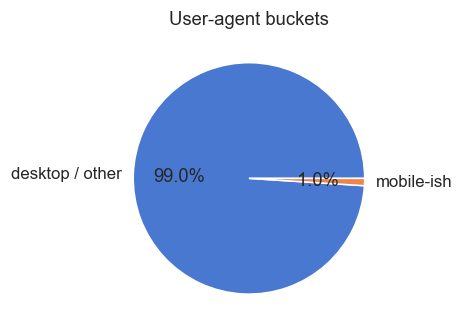

In [14]:
ua_mix = pd.read_sql(
    text(
        """
        SELECT
            CASE
                WHEN user_agent IS NULL OR TRIM(user_agent) = '' THEN 'null / empty'
                WHEN LOWER(user_agent) REGEXP 'bot|crawl|spider|scrape|updown|monitor|pingdom|checker' THEN
                    'bot / monitor'
                WHEN LOWER(user_agent)
                     REGEXP 'mobile|iphone|android.*mobile|ipad|ipod|blackberry|windows phone|opera mini' THEN 'mobile-ish'
                ELSE 'desktop / other'
            END AS ua_bucket,
            COUNT(*) AS n
        FROM tmp_audit_telemetry
        WHERE company_id IS NOT NULL AND company_id <> 97 AND user_id IS NOT NULL AND user_id <> 0
        GROUP BY 1
        ORDER BY n DESC
        """
    ),
    conn,
)
display(ua_mix.assign(pct=lambda d: (100 * d["n"] / d["n"].sum()).round(2)))

_fig, _ax = plt.subplots(figsize=(5, 3.2))
_ax.pie(ua_mix["n"], labels=ua_mix["ua_bucket"], autopct="%1.1f%%")
_ax.set_title("User-agent buckets")
plt.tight_layout()
plt.show()


### 10.a Browser families (`user_agent`)

**Browser** uses order-sensitive `CASE` (Edge before Chrome, Chrome before Safari). **`bot / monitor`** matches §10-style keywords.

**Device** uses the same **mobile-ish** regex as §10 (`mobile`, `iphone`, `ipad`, …) vs **`desktop`**; bots → **`bot`**; missing UA → **`unknown`**.

Chart: **stacked** bars so **mobile** sits beside **desktop** for each browser row.


,browser_family,device_kind,n,pct
1,Chrome,desktop,560863,78.72
0,Edge,desktop,122579,17.20
4,Firefox,desktop,13106,1.84
3,Safari,desktop,7172,1.01
2,Chrome,mobile,3741,0.53
5,Safari,mobile,3425,0.48
6,Opera,desktop,1586,0.22
7,Samsung Internet,mobile,28,0.00
9,Samsung Internet,desktop,11,0.00
8,other,mobile,5,0.00


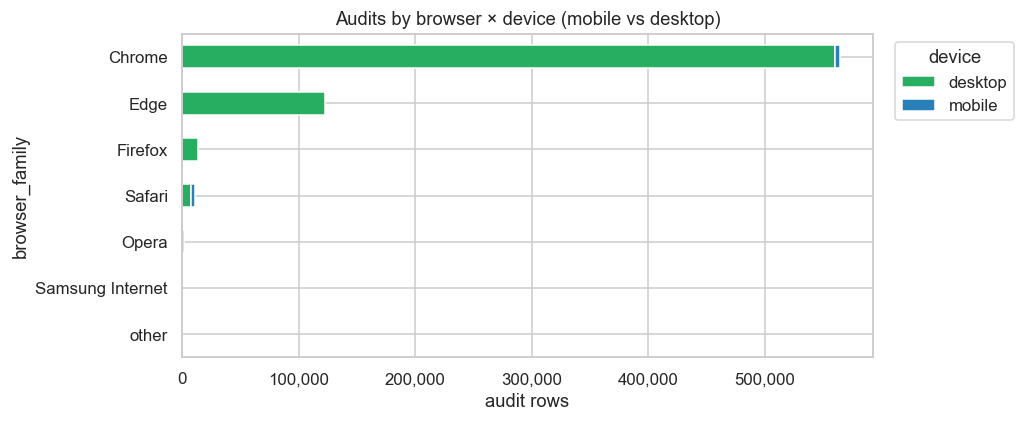

In [15]:
browser_mix = pd.read_sql(
    text(
        """
        SELECT browser_family, device_kind, COUNT(*) AS n
        FROM (
            SELECT
                CASE
                    WHEN user_agent IS NULL OR TRIM(CAST(user_agent AS CHAR)) = '' THEN '(empty)'
                    WHEN LOWER(user_agent) REGEXP 'bot|crawl|spider|scrape|updown|monitor|pingdom|checker'
                        THEN 'bot / monitor'
                    WHEN user_agent LIKE '%Edg/%' OR user_agent LIKE '%Edge/%' THEN 'Edge'
                    WHEN user_agent LIKE '%OPR/%' OR LOWER(user_agent) LIKE '%opr/%' THEN 'Opera'
                    WHEN user_agent LIKE '%Firefox%' OR user_agent LIKE '%FxiOS%' THEN 'Firefox'
                    WHEN user_agent LIKE '%SamsungBrowser%' THEN 'Samsung Internet'
                    WHEN user_agent LIKE '%Chrome%' OR user_agent LIKE '%CriOS%' OR user_agent LIKE '%CrMo%' THEN 'Chrome'
                    WHEN user_agent LIKE '%Safari%' THEN 'Safari'
                    WHEN user_agent LIKE '%MSIE%' OR user_agent LIKE '%Trident/%' THEN 'Internet Explorer'
                    ELSE 'other'
                END AS browser_family,
                CASE
                    WHEN user_agent IS NULL OR TRIM(CAST(user_agent AS CHAR)) = '' THEN 'unknown'
                    WHEN LOWER(user_agent) REGEXP 'bot|crawl|spider|scrape|updown|monitor|pingdom|checker'
                        THEN 'bot'
                    WHEN LOWER(user_agent)
                         REGEXP 'mobile|iphone|android.*mobile|ipad|ipod|blackberry|windows phone|opera mini'
                        THEN 'mobile'
                    ELSE 'desktop'
                END AS device_kind
            FROM tmp_audit_telemetry
            WHERE company_id IS NOT NULL AND company_id <> 97 AND user_id IS NOT NULL AND user_id <> 0
        ) AS u
        GROUP BY browser_family, device_kind
        """
    ),
    conn,
)

_tot = browser_mix["n"].sum()
display(browser_mix.sort_values("n", ascending=False).assign(pct=lambda d: (100 * d["n"] / _tot).round(2)))

_pv = browser_mix.pivot_table(index="browser_family", columns="device_kind", values="n", fill_value=0)
_order = [c for c in ("desktop", "mobile", "bot", "unknown") if c in _pv.columns]
_order += [c for c in _pv.columns if c not in _order]
_pv = _pv[_order]
_pv = _pv.assign(_t=_pv.sum(axis=1)).sort_values("_t").drop(columns=["_t"])

_colors = {"desktop": "#27ae60", "mobile": "#2980b9", "bot": "#7f8c8d", "unknown": "#bdc3c7"}
_bar_colors = [_colors.get(c, "#95a5a6") for c in _pv.columns]

_fig, _ax = plt.subplots(figsize=(9.5, max(4.0, len(_pv) * 0.42)))
_pv.plot(kind="barh", stacked=True, ax=_ax, color=_bar_colors)
_ax.set_xlabel("audit rows")
_ax.set_title("Audits by browser × device (mobile vs desktop)")
_ax.legend(title="device", bbox_to_anchor=(1.02, 1), loc="upper left")
_comma_x(_ax)
plt.tight_layout()
plt.show()



### 11. Traffic concentration across companies

Share of all events coming from **top-N** companies (by row count).


,cohort,share_of_events_pct
0,top 10,17.59
1,top 50,39.81
2,top 100,53.71


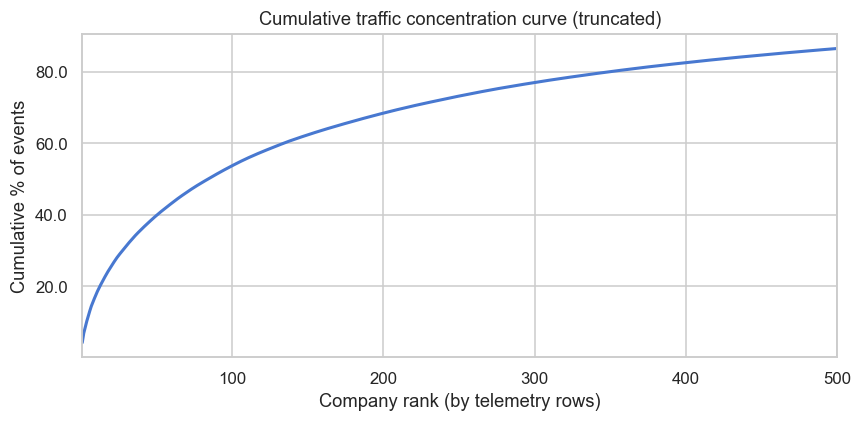

In [16]:
comps = pd.read_sql(
    text(
        """
        SELECT company_id, COUNT(*) AS n
        FROM tmp_audit_telemetry
        WHERE company_id IS NOT NULL AND company_id <> 97 AND user_id IS NOT NULL AND user_id <> 0
        GROUP BY company_id
        ORDER BY n DESC
        """
    ),
    conn,
)
total = comps["n"].sum()
_summary = pd.DataFrame(
    {
        "cohort": ["top 10", "top 50", "top 100"],
        "share_of_events_pct": [
            round(100 * comps.head(10)["n"].sum() / total, 2),
            round(100 * comps.head(50)["n"].sum() / total, 2),
            round(100 * comps.head(100)["n"].sum() / total, 2),
        ],
    }
)
display(_summary)

_curves = comps.reset_index(drop=True).assign(rank=lambda d: d.index + 1, cum_pct=lambda d: d["n"].cumsum() / total)
_cap = min(500, len(_curves))
_fig, _ax = plt.subplots(figsize=(8, 4))
_ax.plot(_curves.loc[: _cap - 1, "rank"], 100 * _curves.loc[: _cap - 1, "cum_pct"], lw=2)
_ax.set_xlim(1, _cap)
_ax.set_ylabel("Cumulative % of events")
_ax.set_xlabel("Company rank (by telemetry rows)")
_ax.set_title("Cumulative traffic concentration curve (truncated)")
_comma_x(_ax)
_ax.yaxis.set_major_formatter(_PCT_AXIS_1DP)
plt.tight_layout()
plt.show()

### 12. Approximate geography (GeoLite2 + plotly)

MaxMind **does not ship** `GeoLite2-City.mmdb` with this repo. The map loads only when this file exists locally (or downloads via **`MAXMIND_LICENSE_KEY`** below).

**Option A — manual (pick one paths the code searches):**

1. Sign up (free): [GeoLite2](https://dev.maxmind.com/geoip/geolite2-free-geolocation-data)
2. Create a **license key** (same account): [License keys](https://www.maxmind.com/en/accounts/current/license-key)
3. Download **GeoLite2-City** (`.tar.gz`), extract **`GeoLite2-City.mmdb`**
4. Put the file in **this folder** (`bansila-dashboard-mvp/`), your **Downloads** folder, **or** set:
   `export GEOIP2_CITY_DB="/full/path/to/GeoLite2-City.mmdb"`

**Option B — auto-download in-notebook:** set **`MAXMIND_LICENSE_KEY`** in the environment (same key as the portal), then re-run the code cell. It saves to **`.geoip_cache/GeoLite2-City.mmdb`** (redirects to Cloudflare R2 are followed automatically).

**Also:** `pip install geoip2 plotly`

Only **IPv4** strings are geocoded here; up to **`MAX_IPS_FOR_GEO`** distinct IPs (by volume).
**Interactive maps:** country-level choropleth plus a **pan/zoom** geo scatter where **darker and larger** markers mean higher event weight (coordinates are rounded and aggregated; true “city heatmaps” need many points at distinct lat/lon — GeoLite2 approximates areas). For a **Mapbox density** layer, set **`MAPBOX_TOKEN`** in the environment (`pip install plotly` includes Mapbox bindings when you use mapbox styles).

**Secrets:** keep **`MAXMIND_LICENSE_KEY`** only in your environment or a secret store; rotate the key in MaxMind if it was ever exposed.


In [17]:
import io
import ipaddress
import math
import os
import tarfile
import urllib.parse
import urllib.request
from pathlib import Path

MAX_IPS_FOR_GEO = 25_000
MAX_POINTS_CITY_MAP = 5_000

_here = Path.cwd().resolve()
_geo_cache = _here / ".geoip_cache"
_geo_cache.mkdir(parents=True, exist_ok=True)

_candidate_dirs = [
    _here,
    _here.parent,
    _here.parent / "bansila-dashboard-mvp",
    Path.home() / "Downloads",
    Path.home() / ".local" / "share" / "GeoIP",
]

_geo_candidates: list[Path] = []
_env_db = os.environ.get("GEOIP2_CITY_DB", "").strip()
if _env_db:
    _geo_candidates.append(Path(_env_db).expanduser().resolve())
for d in _candidate_dirs:
    _geo_candidates.append((d / "GeoLite2-City.mmdb").resolve())
_geo_candidates.append((_geo_cache / "GeoLite2-City.mmdb").resolve())


def _first_existing(paths: list[Path]) -> Path | None:
    for p in paths:
        if p is not None and p.is_file():
            return p
    return None


ip_agg = pd.read_sql(
    text(
        """
        SELECT ip_address, COUNT(*) AS n
        FROM tmp_audit_telemetry
        WHERE company_id IS NOT NULL AND company_id <> 97 AND user_id IS NOT NULL AND user_id <> 0
          AND ip_address IS NOT NULL AND TRIM(ip_address) <> ''
          AND ip_address REGEXP '^[0-9.]+$'
        GROUP BY ip_address
        ORDER BY n DESC
        LIMIT :lim
        """
    ),
    conn,
    params={"lim": int(MAX_IPS_FOR_GEO)},
)

_geo_path = _first_existing(_geo_candidates)

_license = os.environ.get("MAXMIND_LICENSE_KEY", "").strip()

if _geo_path is None and _license:
    _url = "https://download.maxmind.com/app/geoip_download?" + urllib.parse.urlencode(
        {"edition_id": "GeoLite2-City", "license_key": _license, "suffix": "tar.gz"}
    )
    print("GeoLite2-City.mmdb not found; downloading via MAXMIND_LICENSE_KEY …")
    try:
        req = urllib.request.Request(_url, headers={"User-Agent": "bansila-telemetry-notebook/1"})
        with urllib.request.urlopen(req, timeout=240) as resp:
            blob = resp.read()
        head = blob[:8000].lower()
        if b"<html" in head or b"please log in" in head:
            raise RuntimeError("GeoIP download returned HTML (check MAXMIND_LICENSE_KEY).")
        dest = _geo_cache / "GeoLite2-City.mmdb"
        with tarfile.open(fileobj=io.BytesIO(blob), mode="r:*") as tf:
            for member in tf.getmembers():
                if member.isfile() and member.name.endswith("GeoLite2-City.mmdb"):
                    with tf.extractfile(member) as f:
                        if f is None:
                            raise RuntimeError("extractfile returned None")
                        dest.write_bytes(f.read())
                    break
            else:
                raise RuntimeError("GeoLite2-City.mmdb not present in archive")
        _geo_path = dest
        print("Wrote", _geo_path)
    except Exception as _e:
        print("Auto-download failed:", _e)
        _geo_path = _first_existing(_geo_candidates)

if _geo_path is None:
    _geo_path = _first_existing(_geo_candidates)

if _geo_path is None:
    print(
        "Skipping map: GeoLite2-City.mmdb missing.\n"
        "  • Manual: extract GeoLite2-City.mmdb into this project, Downloads, or set GEOIP2_CITY_DB.\n"
        "  • Auto: export MAXMIND_LICENSE_KEY from https://www.maxmind.com/en/accounts/current/license-key and re-run."
    )
    display(ip_agg.head(10))
else:
    try:
        import geoip2.database
    except ImportError:
        print("Install geoip2: pip install geoip2")
        display(ip_agg.head(10))
    else:
        reader = geoip2.database.Reader(str(_geo_path))
        rows: list[dict] = []
        skip_w = {"private": 0, "lookup": 0}
        for ipa, wt in zip(ip_agg["ip_address"], ip_agg["n"]):
            wt = int(wt)
            try:
                sip = str(ipa).strip()
                ip_o = ipaddress.ip_address(sip)
                if not ip_o.is_global:
                    skip_w["private"] += wt
                    continue
                rec = reader.city(sip)
                iso2 = rec.country.iso_code or ""
                cname = (rec.country.name or "").strip()
                city_n = (rec.city.name or "").strip() if rec.city is not None else ""
                lat = rec.location.latitude
                lon = rec.location.longitude
                rows.append(
                    {
                        "iso2": iso2 or "UNKNOWN",
                        "country_name": cname,
                        "city": city_n or "—",
                        "lat": lat,
                        "lon": lon,
                        "weight": wt,
                    }
                )
            except Exception:
                skip_w["lookup"] += wt
        reader.close()

        _df = pd.DataFrame(rows)
        cmap_df = _df.groupby("iso2", as_index=False)["weight"].sum()
        display(cmap_df.sort_values("weight", ascending=False).head(15))
        print("Weights skipped (~private / lookup errors):", skip_w)

        try:
            import plotly.express as px

            # Plotly 6+: choropleth locationmode must be ISO-3, USA-states, country names, or geojson-id
            _country = (
                _df[_df["country_name"].astype(str).str.len() > 0]
                .groupby("country_name", as_index=False)["weight"]
                .sum()
            )
            if _country.empty:
                print("No country names from GeoIP; skipping choropleth.")
            else:
                fig_geo = px.choropleth(
                    _country,
                    locations="country_name",
                    locationmode="country names",
                    color="weight",
                    color_continuous_scale="Blues",
                    title="Event weight by country (GeoLite2, capped distinct IPs)",
                )
                fig_geo.update_layout(margin=dict(l=0, r=0, t=40, b=0))
                fig_geo.update_coloraxes(colorbar_tickformat=",.0f")
                fig_geo.show()

            _pts = _df.dropna(subset=["lat", "lon"]).copy()
            if _pts.empty:
                print("No lat/lon in GeoIP results for city-level map.")
            else:
                _pts["lat_r"] = _pts["lat"].round(4)
                _pts["lon_r"] = _pts["lon"].round(4)
                city_agg = (
                    _pts.groupby(["lat_r", "lon_r", "country_name", "city"], as_index=False)["weight"]
                    .sum()
                    .sort_values("weight", ascending=False)
                    .head(int(MAX_POINTS_CITY_MAP))
                )
                city_agg["size_w"] = city_agg["weight"].apply(lambda w: max(3.0, 4.0 + 8.0 * math.log1p(float(w))))

                fig_city = px.scatter_geo(
                    city_agg,
                    lat="lat_r",
                    lon="lon_r",
                    color="weight",
                    size="size_w",
                    hover_name="city",
                    hover_data={
                        "country_name": True,
                        "weight": True,
                        "lat_r": ":.4f",
                        "lon_r": ":.4f",
                        "size_w": False,
                    },
                    color_continuous_scale="YlOrRd",
                    projection="natural earth",
                    title="Intensity by inferred location (zoom/pan); darker & larger ≈ more events (coords rounded)",
                )
                fig_city.update_traces(marker=dict(line=dict(width=0.3, color="darkred"), opacity=0.78))
                fig_city.update_geos(
                    showcountries=True,
                    countrycolor="lightgray",
                    showland=True,
                    landcolor="whitesmoke",
                    fitbounds="locations",
                )
                fig_city.update_layout(margin=dict(l=0, r=0, t=50, b=0))
                fig_city.update_coloraxes(colorbar_tickformat=",.0f")
                fig_city.show()

            _mb = os.environ.get("MAPBOX_TOKEN", "").strip()
            if _mb and not _pts.empty:
                try:
                    dmb = (
                        _pts.groupby(["lat_r", "lon_r"], as_index=False)["weight"]
                        .sum()
                        .sort_values("weight", ascending=False)
                        .head(int(MAX_POINTS_CITY_MAP))
                    )
                    fig_den = px.density_mapbox(
                        dmb,
                        lat="lat_r",
                        lon="lon_r",
                        z="weight",
                        radius=22,
                        zoom=1,
                        mapbox_style="carto-positron",
                        color_continuous_scale="YlOrRd",
                        title="Optional density heatmap (needs MAPBOX_TOKEN)",
                    )
                    fig_den.update_layout(margin=dict(l=0, r=0, t=40, b=0))
                    fig_den.update_coloraxes(colorbar_tickformat=",.0f")
                    fig_den.show()
                except Exception as _dmbe:
                    print("density_mapbox skipped:", _dmbe)
        except ImportError:
            print("Install plotly for interactive maps: pip install plotly")
            _fig_fb, _ax_fb = plt.subplots(figsize=(7, 4.2))
            _iso = cmap_df[cmap_df["iso2"].str.fullmatch("[A-Z]{2}", na=False)]
            _rank = _iso.sort_values("weight", ascending=False).head(12).iloc[::-1]
            _ax_fb.barh(_rank["iso2"], _rank["weight"], color="steelblue")
            _ax_fb.set_xlabel("event weight")
            _ax_fb.set_title("Top countries")
            _comma_x(_ax_fb)
            plt.tight_layout()
            plt.show()


,iso2,weight
13,LA,693163
7,HK,5834
21,VN,2558
20,US,2291
1,AU,1580
19,TH,1368
18,SG,1210
6,GB,950
15,MY,374
14,MM,315


Weights skipped (~private / lookup errors): {'private': 0, 'lookup': 0}


### 13. Request body (`parameters` JSON)

`parameters` is usually a **JSON object** (string keys) mirroring **request payload / validated input** after Laravel handles the HTTP request. Empty `{}`, `[]`, SQL `NULL`, and JSON `null` are treated as “no payload” elsewhere in this notebook; §13 focuses on rows where the column is a **non-empty object**.

**Outputs:** key frequency table, **(controller, action, key)** combinations for segmentation, **value kind** mix from a random Python parse sample, and short **example previews** per key.

**Deep-dive ideas:** slice `param_route_top` on one key (e.g. `type`, `status`) and time-bin `created_at`; compare IDs appearing in `parameters` vs `route_parameters`; build dashboards on numeric keys after confirming kinds are stable.


,n_identified_rows,n_params_object_nonempty
0,712516,711622.0


Top-level keys (one row may contribute multiple keys):


,param_key,n_rows,pct_of_nonempty_rows
0,_token,621241,87.30
1,_method,358056,50.32
2,currency_rate,291028,40.90
3,reference,275031,38.65
4,description,268056,37.67
5,currency_code,252715,35.51
6,amount,225915,31.75
7,ref_id,224367,31.53
8,type,188806,26.53
9,category_id,163226,22.94


(controller, action, param_key) — top 100 rows:


,controller,action,param_key,n_rows
0,App\Http\Controllers\Accounting\JournalEntries,update,amount,71775
1,App\Http\Controllers\Accounting\JournalEntries,update,credit_code,71775
2,App\Http\Controllers\Accounting\JournalEntries,update,ref_id,71775
3,App\Http\Controllers\Accounting\JournalEntries,update,description,71775
4,App\Http\Controllers\Accounting\JournalEntries,update,type,71775
5,App\Http\Controllers\Accounting\JournalEntries,update,debit_code,71775
6,App\Http\Controllers\Accounting\JournalEntries,update,currency_code,71775
7,App\Http\Controllers\Accounting\JournalEntries,update,currency_rate,71775
8,App\Http\Controllers\Accounting\JournalEntries,update,date,71775
9,App\Http\Controllers\Accounting\JournalEntries,store,_token,65041


Value kinds per key (Bernoulli sample up to 8000 rows, no ORDER BY RAND):


,param_key,value_kind,n_in_sample
0,2fa,string,32
1,_method,string,3899
2,_token,string,6944
4,account_id,string,1395
3,account_id,null,36
5,account_type,string,9
7,accounting_code,string,64
6,accounting_code,null,40
8,accounting_code_admin,null,61
9,accounting_code_admin,string,1


Example previews (up to 3 per key from sample):


,param_key,example_values,n_rows,pct_of_nonempty_rows
2,_token,SZjRQ54fMI2wjZQTCQ66SN04CskHfnfTT5Co6OZr | SZj...,621241,87.30
3,_method,post | post | post,358056,50.32
14,currency_rate,1 | 1 | 1,291028,40.90
8,reference,None | PV-Feb-0018 | None,275031,38.65
24,description,ຈ່າຍຄ່າມັດຈໍາຜະລິດຖົງຢາງ | ມອບເງິນເຂົ້າບັນຊີອາ...,268056,37.67
13,currency_code,LAK | LAK | LAK,252715,35.51
19,amount,990000 | 15223000 | 1875,225915,31.75
20,ref_id,227928 | 1094321 | 227768,224367,31.53
30,type,movement_out | expense | movement_in,188806,26.53
9,category_id,53019 | 36017 | 63102,163226,22.94


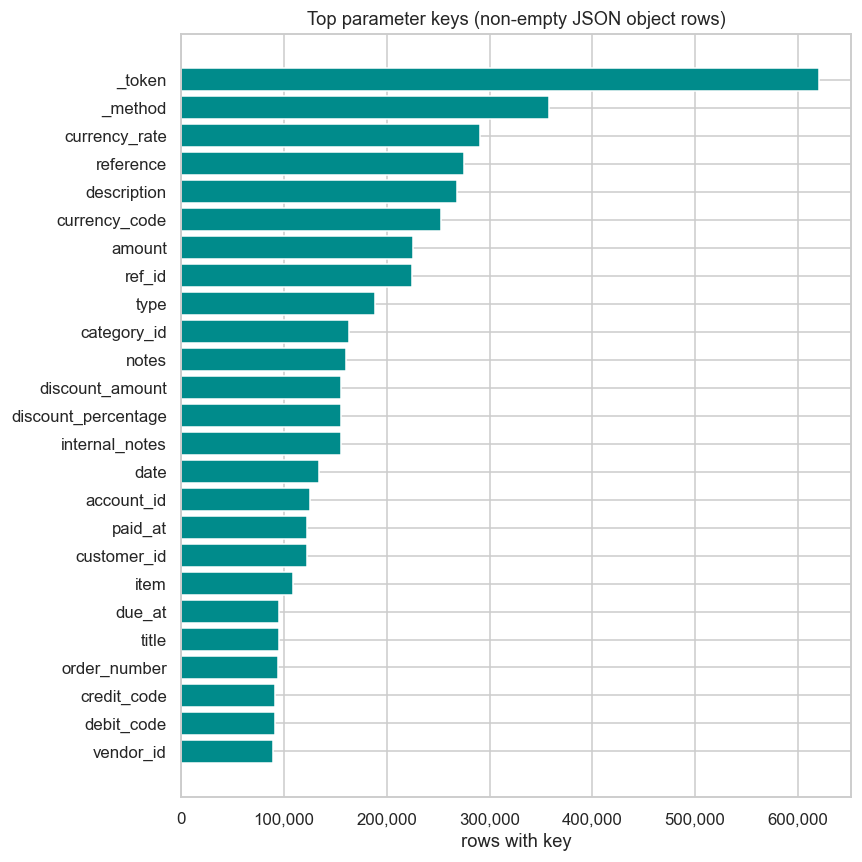

In [18]:
import json
from collections import defaultdict

_IDENTIFIED_WHERE = (
    "company_id IS NOT NULL AND company_id <> 97 "
    "AND user_id IS NOT NULL AND user_id <> 0"
)

_PARAM_OBJ_POPULATED = (
    "parameters IS NOT NULL "
    "AND JSON_TYPE(parameters) = 'OBJECT' "
    "AND JSON_LENGTH(parameters) > 0 "
    "AND NOT (TRIM(CAST(parameters AS CHAR)) IN ('[]', '{}') OR JSON_TYPE(parameters) = 'NULL')"
)

meta_params = pd.read_sql(
    text(f"""
    SELECT
      COUNT(*) AS n_identified_rows,
      SUM(CASE WHEN {_PARAM_OBJ_POPULATED} THEN 1 ELSE 0 END) AS n_params_object_nonempty
    FROM tmp_audit_telemetry
    WHERE {_IDENTIFIED_WHERE}
    """),
    conn,
)
display(meta_params)

sql_keys = f"""
SELECT jt.param_key AS param_key, COUNT(*) AS n_rows
FROM tmp_audit_telemetry t
JOIN JSON_TABLE(
  JSON_KEYS(t.parameters),
  '$[*]' COLUMNS (param_key VARCHAR(191) PATH '$')
) AS jt
WHERE {_IDENTIFIED_WHERE}
  AND {_PARAM_OBJ_POPULATED}
GROUP BY jt.param_key
ORDER BY n_rows DESC
"""

param_key_counts = pd.read_sql(text(sql_keys), conn)
n_nonempty = int(meta_params["n_params_object_nonempty"].iloc[0] or 0)
if n_nonempty > 0:
    param_key_counts["pct_of_nonempty_rows"] = (100 * param_key_counts["n_rows"] / n_nonempty).round(2)
print("Top-level keys (one row may contribute multiple keys):")
display(param_key_counts.head(80))

sql_route_key = f"""
SELECT
  t.controller AS controller,
  t.action AS action,
  jt.param_key AS param_key,
  COUNT(*) AS n_rows
FROM tmp_audit_telemetry t
JOIN JSON_TABLE(
  JSON_KEYS(t.parameters),
  '$[*]' COLUMNS (param_key VARCHAR(191) PATH '$')
) AS jt
WHERE {_IDENTIFIED_WHERE}
  AND {_PARAM_OBJ_POPULATED}
GROUP BY t.controller, t.action, jt.param_key
ORDER BY n_rows DESC
LIMIT 100
"""

param_route_top = pd.read_sql(text(sql_route_key), conn)
print("(controller, action, param_key) — top 100 rows:")
display(param_route_top)

SAMPLE_N = 8000
# Avoid ORDER BY RAND(): MySQL must sort every matching row → error 1038 / sort buffer on large heaps.
# Bernoulli row acceptance (no sort): scan rows and keep each with probability p until LIMIT.
_n_pop = max(int(meta_params["n_params_object_nonempty"].iloc[0] or 0), 1)
_p_take = float(min(1.0, (SAMPLE_N * 5.0) / _n_pop))
raw_sample = pd.read_sql(
    text(f"""
    SELECT parameters
    FROM tmp_audit_telemetry
    WHERE {_IDENTIFIED_WHERE}
      AND {_PARAM_OBJ_POPULATED}
      AND RAND() < :p_take
    LIMIT :lim
    """),
    conn,
    params={"p_take": _p_take, "lim": SAMPLE_N},
)
if len(raw_sample) < SAMPLE_N // 2 and _p_take < 1.0:
    raw_sample = pd.read_sql(
        text(f"""
        SELECT parameters
        FROM tmp_audit_telemetry
        WHERE {_IDENTIFIED_WHERE}
          AND {_PARAM_OBJ_POPULATED}
        LIMIT :lim
        """),
        conn,
        params={"lim": SAMPLE_N},
    )


def _json_kind(v):
    if v is None:
        return "null"
    if isinstance(v, bool):
        return "boolean"
    if isinstance(v, int) and not isinstance(v, bool):
        return "integer"
    if isinstance(v, float):
        return "number"
    if isinstance(v, str):
        return "string"
    if isinstance(v, list):
        return f"array(len={len(v)})"
    if isinstance(v, dict):
        return f"object(keys={len(v)})"
    return type(v).__name__


kind_rows = []
examples = defaultdict(list)

for raw in raw_sample["parameters"]:
    try:
        obj = raw if isinstance(raw, dict) else json.loads(raw)
    except (json.JSONDecodeError, TypeError):
        continue
    if not isinstance(obj, dict):
        continue
    for k, v in obj.items():
        kind_rows.append({"param_key": k, "value_kind": _json_kind(v)})
        if len(examples[k]) < 3:
            preview = v
            if isinstance(v, (dict, list)):
                preview = str(v)[:140]
            elif isinstance(v, str) and len(v) > 100:
                preview = v[:100] + "…"
            examples[k].append(preview)

if kind_rows:
    kv = pd.DataFrame(kind_rows)
    kind_mix = (
        kv.groupby(["param_key", "value_kind"])
        .size()
        .reset_index(name="n_in_sample")
        .sort_values(["param_key", "n_in_sample"], ascending=[True, False])
    )
    print(f"Value kinds per key (Bernoulli sample up to {SAMPLE_N} rows, no ORDER BY RAND):")
    display(kind_mix.head(100))

    ex_df = pd.DataFrame(
        [{"param_key": k, "example_values": " | ".join(map(str, vals))} for k, vals in examples.items()]
    )
    ex_df = ex_df.merge(
        param_key_counts[["param_key", "n_rows", "pct_of_nonempty_rows"]],
        on="param_key",
        how="left",
    ).sort_values("n_rows", ascending=False)
    print("Example previews (up to 3 per key from sample):")
    display(ex_df.head(50))
else:
    print("No JSON objects parsed from sample.")

if len(param_key_counts) > 0:
    _cap = min(25, len(param_key_counts))
    _top = param_key_counts.head(_cap).iloc[::-1]
    _fig, _ax = plt.subplots(figsize=(8, max(3.8, _cap * 0.32)))
    _ax.barh(_top["param_key"], _top["n_rows"], color="darkcyan")
    _ax.set_xlabel("rows with key")
    _ax.set_title("Top parameter keys (non-empty JSON object rows)")
    _comma_x(_ax)
    plt.tight_layout()
    plt.show()
